<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Project_2_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Stock Price Prediction


# Introduction

This project is about predicting stock prices by using **Long Short-Term Memory (LSTM)** networks.
I used the dataset Apple stock data (`AAPL.csv`) and predict future prices based on historical trends.


# Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving AAPL.csv to AAPL.csv


# Loading and Exploring the Data

In [2]:
import pandas as pd

df = pd.read_csv('AAPL.csv')
df.head()

,datetime,open,high,low,close,volume
0,1998-01-02,0.12,0.14,0.12,0.14,170539824
1,1998-01-05,0.14,0.14,0.13,0.14,152723900
2,1998-01-06,0.14,0.17,0.13,0.16,433041952
3,1998-01-07,0.16,0.16,0.15,0.15,251914152
4,1998-01-08,0.15,0.16,0.15,0.16,188994988


In [21]:
# Standardizing Column Names
df.columns = df.columns.str.lower()
df.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6639 entries, 0 to 6638
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  6639 non-null   datetime64[ns]
 1   open      6639 non-null   float64       
 2   high      6639 non-null   float64       
 3   low       6639 non-null   float64       
 4   close     6639 non-null   float64       
 5   volume    6639 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 311.3 KB


In [23]:
df.describe()

,datetime,open,high,low,close,volume
count,6639,6639.000000,6639.000000,6639.000000,6639.000000,6.639000e+03
mean,2011-03-10 09:03:46.118391296,35.199886,35.570598,34.842282,35.223116,9.717638e+07
min,1998-01-02 00:00:00,0.120000,0.140000,0.120000,0.140000,2.289900e+04
25%,2004-08-10 12:00:00,1.020000,1.050000,0.990000,1.010000,3.979887e+07
50%,2011-03-14 00:00:00,12.070000,12.180000,11.940000,12.070000,7.154295e+07
75%,2017-10-14 12:00:00,39.365000,39.675000,38.990000,39.285000,1.249616e+08
max,2024-03-13 00:00:00,198.020000,199.620000,197.090000,198.010000,1.588296e+09
std,NaN,52.466733,53.010690,51.957328,52.513064,8.677572e+07


In [25]:
# Handling the Missing Values
df.isnull().sum()

,0
datetime,0
open,0
high,0
low,0
close,0
volume,0


In [26]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [27]:
# Standardizing the column names
df.columns = df.columns.str.lower()

df.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [28]:
# Converting datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

In [29]:
# Selecting the Close Price
data = df[['close']].values

In [30]:
# Normalizing Data (0–1 Scaling)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [31]:
# Creating Sequences (5 Days -> Predict Next Day)
X = []
y = []

for i in range(5, len(scaled_data)):
    X.append(scaled_data[i-5:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

X.shape, y.shape

((6634, 5, 1), (6634,))

In [32]:
# Train-Test Split (90% - 10%)
split = int(0.9 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape, X_test.shape

((5970, 5, 1), (664, 5, 1))

In [33]:
# Building LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Training Model
history = model.fit(X_train, y_train, epochs=10, batch_size=1)

Epoch 1/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 2.9645e-04
Epoch 2/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 1.5204e-04
Epoch 3/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 1.1800e-04
Epoch 4/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - loss: 8.8277e-05
Epoch 5/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 9.5028e-05
Epoch 6/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 7.0255e-05
Epoch 7/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 7.6180e-05
Epoch 8/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 6.2711e-05
Epoch 9/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 5.3327e-05
Epoch 10/10
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 5.4479e-05


# Making the Predictions

In [35]:
predictions = model.predict(X_test)

# Converting it back to original values
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


# Model Evaluation (RMSE)

In [36]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 9.338169649742971


# Visualization

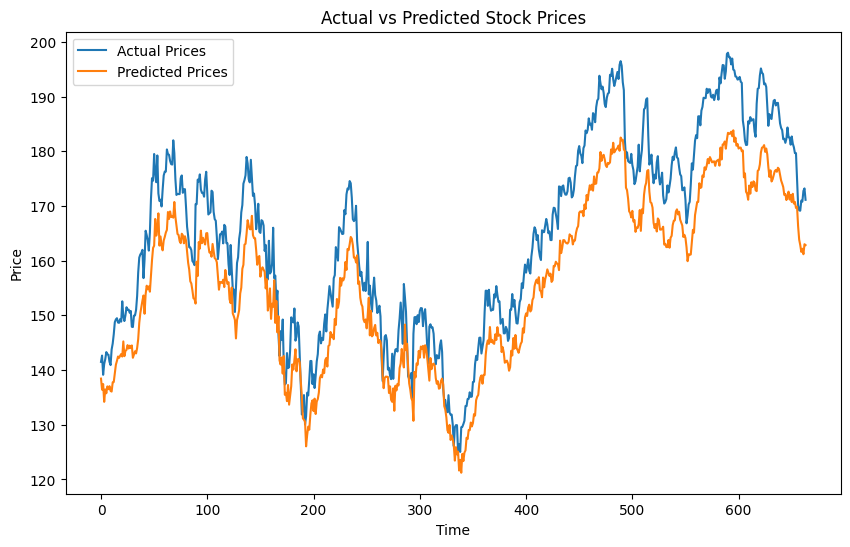

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Comparison with ARIMA Model

In [39]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(data, order=(5,1,0))
model_arima_fit = model_arima.fit()

forecast = model_arima_fit.forecast(steps=len(y_test))

rmse_arima = math.sqrt(mean_squared_error(y_test_actual.flatten(), forecast))
print("ARIMA RMSE:", rmse_arima)

ARIMA RMSE: 18.961931170012893



# Conclusion

- LSTM captures time dependencies better than traditional model ones.
- RMSE has helped check for accuracy.
- ARIMA gives a baseline comparison.
